# Nonlinear Heat Conduction in a Rod with a Heater Schedule

This tutorial solves a nonlinear parabolic PDE with the orthogonal-collocation-on-finite-elements solver `OCFESLV` of the library `cronos` (CRONOS), the model being declared on a DAG of `pymcpp` (MC++). The PDE is solved both **monolithically** (all time elements at once) and by **marching** (one time element after the other); the solution field is read back anywhere through `eval_solution`; and the outputs are differentiated with respect to a time-varying control.

A rod $z \in [0,1]$ is held at temperature $0$ at $z=0$ and heated at $z=1$ by a heater of power $q(t)$. Its thermal conductivity increases with temperature, so heat conduction is **nonlinear**:
$$\begin{align*}
  \frac{\partial u}{\partial t} &= \frac{\partial}{\partial z}\left( D(u)\,\frac{\partial u}{\partial z} \right), \qquad D(u) = D_0\,(1 + \beta u), && z \in (0,1),\ t \in (0,1]\\
  u(t,0) &= 0, \qquad D(u)\,\frac{\partial u}{\partial z}(t,1) = q(t) && t \in (0,1]\\
  u(0,z) &= a\,z && z \in [0,1]
\end{align*}$$
with $D_0 = 0.1$ and $\beta = 1$. The initial profile is the linear one that carries the initial heater power, $D_0(1+\beta a)\,a = q(0)$, so that the initial and boundary data are compatible.

The heater is turned down gradually, from full power to a quarter of it: $q(t) = 0.625 + 0.375\cos(\pi t)$. The outputs of interest are the temperature at the heated end at the final time, $u(1,1)$, and the space-time mean temperature $\int_0^1\!\int_0^1 u\,dz\,dt$.

We start by importing the `pymcpp` and `cronos` libraries.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

import pymcpp
import cronos
from pymcpp import FFGraph, FFPartial, FFEval, FFIntegral
from cronos import FFDom, FFModel, OCFESLV, FFOCFESLV

## The model

The model lives on a DAG: the independent variables $t$ and $z$, the state $u(t,z)$ and the input $q(t)$. Derivatives, point evaluations and integrals along the domains are DAG operations: `FFPartial`, `FFEval` and `FFIntegral`.

Each domain is partitioned into finite elements, with collocation nodes of a given family in each element: Legendre-Gauss-Radau (`LGR`) in time, which suits an evolution direction, and Legendre-Gauss-Lobatto (`LGL`) in space, whose nodes include the element ends.

In [2]:
D0, beta = 0.1, 1.0
NT, NZ = 10, 8                       # time and space elements

# initial profile a z, with D0 (1 + beta a) a = q(0) = 1
a = (-1. + np.sqrt(1. + 4. * beta / D0)) / (2. * beta)
print("initial slope a = %.6f" % a)

def heater(tv):
    """Heater power at time tv."""
    return 0.625 + 0.375 * np.cos(np.pi * tv)

OpP, OpE, OpI = FFPartial(), FFEval(), FFIntegral()
Role = FFModel.EqnRole

initial slope a = 2.701562


The solver `OCFESLV` is populated through the `FFModel` interface: the domains (with the evolution direction $t$), the state and the input with their reference values, the equations with their region and role, and the outputs.

The flux form $\partial_z(D(u)\,\partial_z u)$ is written expanded, $D(u)\,u_{zz} + D_0\beta\,u_z^2$. The second derivative is reduced to first order automatically (an auxiliary state $\partial_z u$ is introduced at `setup()`). The regions are given by masks: `FFDom.ALL - FFDom.LB` is $(0,1]$, and so on. The heater input is discretised on the time elements with 3 Lobatto nodes each (`LGL`, `n_node=3`): a quadratic in every element, with nodes at both element ends, so that the heater schedule is continuous from one element to the next.

In [3]:
def build_model(marching=False):
    """The heated-rod model in a new OCFESLV solver."""
    G = FFGraph()
    t, z = G.add_var("t"), G.add_var("z")
    u, q = G.add_var("u"), G.add_var("q")

    S = OCFESLV(G)
    S.add_domain(t, FFDom(0., 1., NT, FFDom.LGR, 3))
    S.add_domain(z, FFDom(0., 1., NZ, FFDom.LGL, 5))
    S.set_evolution_domain(t)
    S.add_state(u, [t, z], ref=0.)
    S.add_input(q, [t], ref=1., type=FFDom.LGL, n_node=3)    # 3 nodes per time element, both ends included

    T_INT = FFDom.ALL - FFDom.LB                    # t in (0, 1]
    Z_INT = FFDom.ALL - FFDom.LB - FFDom.UB         # z in (0, 1)
    D = D0 * (1. + beta * u)
    S.add_equation(OpP(u, t) - D * OpP(u, {z: 2}) - D0 * beta * OpP(u, z)**2,
                   [t, z], [T_INT, Z_INT], OCFESLV.EqnOptions(Role.INTERIOR))
    S.add_equation(u, [t, z], [T_INT, FFDom.LB],
                   OCFESLV.EqnOptions(Role.BOUNDARY))          # u(t,0) = 0
    S.add_equation(D * OpP(u, z) - q, [t, z], [T_INT, FFDom.UB],
                   OCFESLV.EqnOptions(Role.BOUNDARY))          # heater flux at z = 1
    S.add_equation(u - a * z, [t, z], [FFDom.LB, FFDom.ALL],
                   OCFESLV.EqnOptions(Role.INITIAL))           # u(0,z) = a z

    S.add_output(OpE(u, {t: 1, z: 1}, {t: 1., z: 1.}))        # u(1,1)
    S.add_output(OpI(u, {t: 1, z: 1}))                         # space-time mean temperature

    S.options.INTERFACE.IMPOSITION = OCFESLV.Options.IC_STRONG
    S.options.SOLVE.MARCHING = marching
    S.options.SOLVE.RES_TOL = 1e-10
    S.options.DISPLAY_LEVEL = 0
    return S, (t, z, u, q)

Interface continuity between elements is imposed **strongly** (`IC_STRONG`): exact continuity rows. The alternative, weak imposition through penalties (`IC_WEAK`, the current default), depends on a penalty strength and is markedly less accurate on this problem at this resolution -- see the note at the end.

## Monolithic solution

`setup()` analyses the model and builds the collocation system; the model report shows what the solver sees: the equations written out with their regions, the auxiliary state introduced by the order reduction, the classification and the degrees of freedom.

In [4]:
S, (t, z, u, q) = build_model()
S.options.DISPLAY_LEVEL = 1
S.setup()
S.options.DISPLAY_LEVEL = 0

OCFESLV::setup ** PLAN: GLOBAL decisions APPLIED: exact=0 tau=350 constraints=350
[determinacy] STRUCTURAL mode=IC_STRONG k_struct=0 proj_applied=0 k_pred=0 deficit=0 deficient_clusters=0 implied_entries=3 over 3 state(s)  (audit OFF: this line replaces the SPQR audit)
OCFESLV::setup [evolution] OK -- var=t type=PARABOLIC sigma_min_evol=0 IC coverage=1/1
OCFESLV::setup [classify] blk0 type=PARABOLIC  sym=2x2 nDom=2 nCoeff=2  Ae_singular=y sigma_min_evol=0 sigma_max_evol=1 imag_tol=1e-08 evol_dom_idx=0 [user-supplied]


The unknowns live in NumPy arrays: `init()` returns the collocation state vector `var`, initialised from the reference values, and the input vector `inp`. `sample_input` writes the heater schedule into `inp` -- a function of the coordinates, evaluated at the input's collocation nodes -- and `solve` overwrites `var` with the solution:

In [5]:
var, inp = S.init()
S.sample_input(q, lambda c: heater(c[t]), inp)

t0 = time.perf_counter()
report = S.solve(var, inp)
cpu_mono = time.perf_counter() - t0
f_mono = S.val_functions()
print(report, " (%.2f s)" % cpu_mono)
print("u(1,1) = %.8f   mean temperature = %.8f" % tuple(f_mono))

SolveReport(converged=True, iterations=5, final_residual=1.00153e-12)  (0.20 s)
u(1,1) = 2.28736842   mean temperature = 1.50907158


## The solution field

`eval_solution(state, point)` reads the converged solution at any point of the domain -- here on a regular grid, for a map of the temperature field:

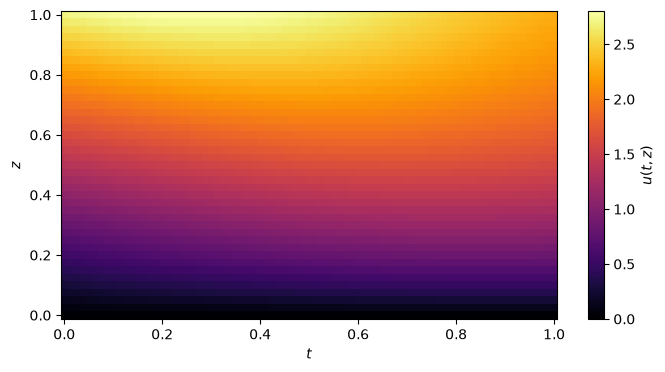

In [6]:
tt = np.linspace(0., 1., 81)
zz = np.linspace(0., 1., 41)
U = np.array([[S.eval_solution(u, {t: tv, z: zv}) for tv in tt] for zv in zz])

fig, ax = plt.subplots(figsize=(8, 4))
pc = ax.pcolormesh(tt, zz, U, shading="auto", cmap="inferno")
ax.set_xlabel("$t$")
ax.set_ylabel("$z$")
fig.colorbar(pc, label="$u(t,z)$")
plt.show()

Temperature profiles along the rod at several times, and the temperature histories at the heated end and in the middle: the heated end warms up while the heater is near full power, then cools down as it is turned down.

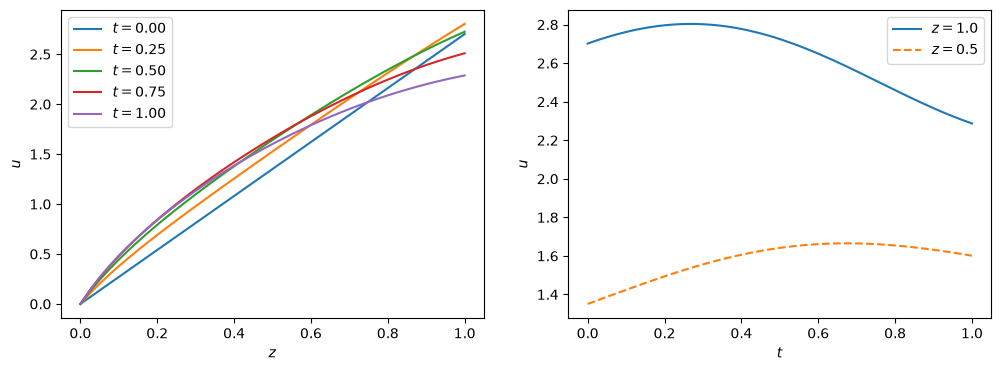

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for tv in (0., 0.25, 0.5, 0.75, 1.):
    ax1.plot(zz, [S.eval_solution(u, {t: tv, z: zv}) for zv in zz], label="$t = %.2f$" % tv)
ax1.set_xlabel("$z$")
ax1.set_ylabel("$u$")
ax1.legend()
for zv, ls in ((1., "-"), (0.5, "--")):
    ax2.plot(tt, [S.eval_solution(u, {t: tv, z: zv}) for tv in tt], ls, label="$z = %.1f$" % zv)
ax2.set_xlabel("$t$")
ax2.set_ylabel("$u$")
ax2.legend()
plt.show()

## Marching

For an evolution problem, the collocation system can also be solved one time element after the other (`options.SOLVE.MARCHING`), each window starting from the end of the previous one. This is much cheaper: each solve is small. With `options.OUTPUT.MARCH_STORE` (on by default), every window is kept, so `eval_solution` reads the full marched field as well:

In [8]:
SM, (tM, zM, uM, qM) = build_model(marching=True)
SM.setup()
varM, inpM = SM.init()
SM.sample_input(qM, lambda c: heater(c[tM]), inpM)

t0 = time.perf_counter()
reportM = SM.solve(varM, inpM)
cpu_march = time.perf_counter() - t0
f_march = SM.val_functions()
print(reportM, " (%.2f s, %d windows)" % (cpu_march, SM.n_march_steps()))
print("u(1,1) = %.8f   mean temperature = %.8f" % tuple(f_march))

UM = np.array([[SM.eval_solution(uM, {tM: tv, zM: zv}) for tv in tt] for zv in zz])
print("monolithic: %.3f s   marching: %.3f s   max |u_mono - u_march| over the grid: %.2e"
      % (cpu_mono, cpu_march, np.abs(U - UM).max()))

SolveReport(converged=True, iterations=32, final_residual=3.15303e-14)  (0.03 s, 10 windows)
u(1,1) = 2.28736842   mean temperature = 1.50907158
monolithic: 0.203 s   marching: 0.029 s   max |u_mono - u_march| over the grid: 9.77e-15


Marching is causal -- each window depends only on the past -- and so is the monolithic time discretisation: every time element starts from the previous element's end state, as a marching window does. The two modes therefore solve the same discretisation and agree to round-off. Marching is several times faster.

## Sensitivities with respect to the heater schedule

The heater input is registered as a **control**: its degrees of freedom are its values at the collocation nodes, 3 per time element. `solve_fsens` (forward) and `solve_asens` (adjoint) then compute the derivatives of the outputs with respect to them, returned by `sens_jacobian()` as an array of shape (outputs, control DOFs):

In [9]:
SS, (tS, zS, uS, qS) = build_model()
SS.register_control(qS)
SS.setup()
varS, inpS = SS.init()
SS.sample_input(qS, lambda c: heater(c[tS]), inpS)

SS.solve_fsens(varS.copy(), inpS)
J_fwd = SS.sens_jacobian()
SS.solve_asens(varS.copy(), inpS)
J_adj = SS.sens_jacobian()
print("sens_jacobian:", J_fwd.shape, "| max |forward - adjoint| = %.2e" % np.abs(J_fwd - J_adj).max())

sens_jacobian: (2, 30) | max |forward - adjoint| = 1.50e-15


A finite-difference check on one degree of freedom: `encode_controls` reads the control values out of `inp`, `decode_controls` writes them back:

In [10]:
k, h = 10, 1e-6
SS.solve(varS.copy(), inpS)
f0 = np.array(SS.val_functions())
p = SS.encode_controls(inpS)
p[k] += h
inp_h = inpS.copy()
SS.decode_controls(p, inp_h)
SS.solve(varS.copy(), inp_h)
fd = (np.array(SS.val_functions()) - f0) / h
print("d outputs / d q_%d: forward %s   finite difference %s" % (k, np.round(J_fwd[:, k], 6), np.round(fd, 6)))

d outputs / d q_10: forward [0.084228 0.049763]   finite difference [0.084228 0.049763]


The sensitivities, plotted at the time of each heater node: the final temperature at the heated end is most sensitive to the last part of the schedule, whereas heating early raises the mean temperature more -- that heat has longer to diffuse in. The tall and short stems alternate because each element has 3 Lobatto nodes: the middle one carries most of the element's weight (2/3), each end 1/6, and each element's end values are degrees of freedom of their own:

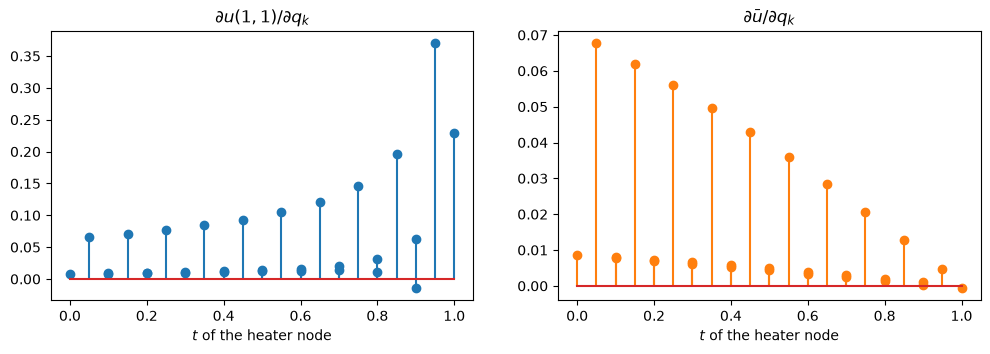

In [11]:
inp_t = inpS.copy()                                              # the time of every heater DOF: fill q(t) = t,
SS.sample_input(qS, lambda c: c[tS], inp_t)                      # then read the DOFs back
t_dof = np.array(SS.encode_controls(inp_t))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
ax1.stem(t_dof, J_fwd[0])
ax1.set_xlabel("$t$ of the heater node")
ax1.set_title(r"$\partial u(1,1) / \partial q_k$")
ax2.stem(t_dof, J_fwd[1], linefmt="C1-", markerfmt="C1o")
ax2.set_xlabel("$t$ of the heater node")
ax2.set_title(r"$\partial \bar u / \partial q_k$")
plt.show()

## The heated rod as a DAG

The solver can also be embedded in a DAG as an external operation, with `FFOCFESLV`: its outputs become DAG variables, functions of the DAG variables given for its inputs, which can then be composed with other DAG operations, evaluated, sampled and differentiated like any other DAG function.

Here the heater schedule is parametrised in the DAG as $q(t) = A + B\cos(\pi t)$, with $A$ and $B$ DAG variables; $A = 0.625$, $B = 0.375$ is the schedule used so far. The heater's degrees of freedom -- its values at the time nodes `t_dof` found above -- become DAG expressions $A + B\cos(\pi t_k)$, passed in the order of the control DOFs. We embed a **marching** solver, the faster of the two. Under the default policy `SHALLOW` the operation refers to the solver, which the DAG keeps alive; `COPY` gives the operation its own copy -- the policy to use when embedding the same solver several times with different inputs.

In [12]:
DAG = FFGraph()
A = DAG.add_var("A")
B = DAG.add_var("B")

SD, (tD, zD, uD, qD) = build_model(marching=True)
SD.options.MAXTHREAD = 1        # one BLAS/OpenMP thread per solve: veval below runs the solves themselves in parallel
SD.setup()

Q = [A + B * np.cos(np.pi * tk) for tk in t_dof]      # the heater DOFs as DAG expressions
OpOCFE = FFOCFESLV()
[uT, ubar] = OpOCFE({qD: Q}, SD)

uT.set("uT")
ubar.set("ubar")
DAG.output([uT, ubar])

print(uT, " = ", uT.str())

  [maxthread] cap=1 via omp(was 16) openblas(was 16) + cholmod.nthreads_max; restored on exit



OPERATIONS IN SUBGRAPH:
  A	<-  VARIABLE
  B	<-  VARIABLE
  Z0	<<  A + B	
  Z1	<<  0.987688(D)	
  Z2	<<  B x Z1	
  Z3	<<  A + Z2	
  Z4	<<  0.951057(D)	
  Z5	<<  B x Z4	
  Z6	<-  A + Z5	
  Z7	<<  0.891007(D)	
  Z8	<<  B x Z7	
  Z9	<<  A + Z8	
  Z10	<<  0.809017(D)	
  Z11	<<  B x Z10	
  Z12	<-  A + Z11	
  Z13	<<  0.707107(D)	
  Z14	<<  B x Z13	
  Z15	<<  A + Z14	
  Z16	<<  0.587785(D)	
  Z17	<<  B x Z16	
  Z18	<-  A + Z17	
  Z19	<<  0.45399(D)	
  Z20	<<  B x Z19	
  Z21	<<  A + Z20	
  Z22	<<  0.309017(D)	
  Z23	<<  B x Z22	
  Z24	<-  A + Z23	
  Z25	<<  0.156434(D)	
  Z26	<<  B x Z25	
  Z27	<<  A + Z26	
  Z28	<<  6.12323e-17(D)	
  Z29	<<  B x Z28	
  Z30	<-  A + Z29	
  Z31	<<  -0.156434(D)	
  Z32	<<  B x Z31	
  Z33	<<  A + Z32	
  Z34	<<  -0.309017(D)	
  Z35	<<  B x Z34	
  Z36	<-  A + Z35	
  Z37	<<  -0.45399(D)	
  Z38	<<  B x Z37	
  Z39	<<  A + Z38	
  Z40	<<  -0.587785(D)	
  Z41	<<  B x Z40	
  Z42	<<  A + Z41	
  Z43	<<  -0.587785(D)	
  Z44	<<  B x Z43	
  Z45	<<  A + Z44	
  Z46	<<  -0.707107

A derived output, the ratio of the final temperature at the heated end to the space-time mean:

In [13]:
ratio = uT / ubar
ratio.set("ratio")

Evaluated at the nominal schedule, the DAG agrees with the solves above:

In [14]:
[uT_val, ubar_val, ratio_val] = DAG.eval([uT, ubar, ratio], [A, B], [0.625, 0.375])
print("u(1,1) = %.8f   mean = %.8f   ratio = %.6f" % (uT_val, ubar_val, ratio_val))
print("from the solve above: u(1,1) = %.8f   mean = %.8f" % tuple(f0))

u(1,1) = 2.28736842   mean = 1.50907158   ratio = 1.515745
from the solve above: u(1,1) = 2.28736842   mean = 1.50907158


Multiple DAG evaluations over the schedule parameters $(A, B) \in [0.25, 1] \times [0, 0.5]$; each evaluation is a complete simulation of the rod:

With `DAG.options.MAXTHREAD = 0`, `veval` spreads the evaluations over all available threads, each thread with its own copy of the embedded solver. The solver itself was therefore limited to a single BLAS/OpenMP thread above (`SD.options.MAXTHREAD = 1`): otherwise each concurrent solve would also start its own pool of linear-algebra threads, oversubscribing the cores.

In [15]:
from scipy.stats import qmc

sampler = qmc.Sobol(d=2, scramble=False, seed=1)
samInput = sampler.random_base2(m=7)                  # 2^7 = 128 evaluations
samInput[:, 0] = 0.25 + samInput[:, 0] * (1. - 0.25)
samInput[:, 1] = samInput[:, 1] * 0.5

DAG.options.MAXTHREAD = 0                             # use all available threads
samOutput = np.array(DAG.veval([uT, ratio], [A, B], samInput.tolist(), walltime=True))
print(samOutput[:5])

[[1.86778294 1.47792063]
 [2.38121714 1.60178033]
 [2.79701735 1.80201211]
 [1.93377577 1.36093696]
 [2.25766486 1.57747114]]


vectorized DAG evaluation on 0 threads: 0.572155 sec


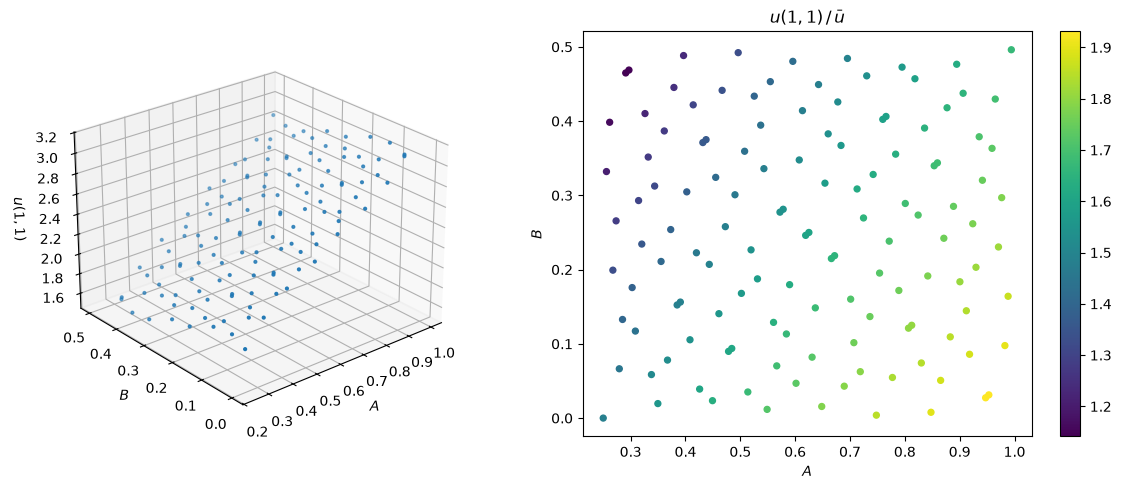

In [16]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(samInput[:, 0], samInput[:, 1], samOutput[:, 0], s=4)
ax.set_xlabel("$A$"); ax.set_ylabel("$B$"); ax.set_zlabel("$u(1,1)$")
ax.view_init(elev=25, azim=230)
ax2 = fig.add_subplot(1, 2, 2)
sc = ax2.scatter(samInput[:, 0], samInput[:, 1], c=samOutput[:, 1], s=18, cmap="viridis")
ax2.set_xlabel("$A$"); ax2.set_ylabel("$B$"); ax2.set_title(r"$u(1,1)\,/\,\bar u$")
fig.colorbar(sc, ax=ax2)
plt.tight_layout()
plt.show()

The derivatives of the outputs with respect to $A$ and $B$ come from the DAG (`fdiff`), which differentiates the embedded solve through the solver's sensitivities. They agree with the chain rule applied to the sensitivity Jacobian computed earlier, since $\partial q_k/\partial A = 1$ and $\partial q_k/\partial B = \cos(\pi t_k)$:

In [17]:
[Row, Col, Grad] = DAG.fdiff([uT, ubar], [A, B])
Grad_val = DAG.eval(Grad, [A, B], [0.625, 0.375])
J_AB = np.zeros((2, 2))
for i, j, g in zip(Row, Col, Grad_val):
    J_AB[i, j] = g
print("DAG fdiff:\n", J_AB)

J_chain = np.column_stack([J_fwd.sum(axis=1), J_fwd @ np.cos(np.pi * t_dof)])
print("chain rule:\n", J_chain)
print("max |difference| = %.1e" % np.abs(J_AB - J_chain).max())

DAG fdiff:
 [[ 1.82635791 -0.75837189]
 [ 0.46914739  0.17941237]]
chain rule:
 [[ 1.82635791 -0.75837189]
 [ 0.46914739  0.17941237]]
max |difference| = 6.7e-15


## Note: strong versus weak interface imposition

With weak imposition (`IC_WEAK`), continuity between spatial elements is enforced by penalty terms of strength `INTERFACE.SAT_SIGMA0` (continuity in time is always exact). Its default value, 10, suits this problem; at 1 the penalty is too weak: the solution is noticeably off, and the two solve modes differ slightly. Much larger values (around 100) can make the monolithic Newton solve fail. Strong imposition needs no such tuning:

In [18]:
for imp, sigma in ((OCFESLV.Options.IC_STRONG, None), (OCFESLV.Options.IC_WEAK, 1.), (OCFESLV.Options.IC_WEAK, 10.)):
    res = []
    for marching in (False, True):
        W, (tW, zW, uW, qW) = build_model(marching=marching)
        W.options.INTERFACE.IMPOSITION = imp
        if sigma: W.options.INTERFACE.SAT_SIGMA0 = sigma
        W.setup()
        vW, iW = W.init()
        W.sample_input(qW, lambda c: heater(c[tW]), iW)
        W.solve(vW, iW)
        res.append(W.val_functions()[0])
    print("%-10s %-14s u(1,1): monolithic %.6f  marching %.6f" % (str(imp).split(".")[-1],
          "" if sigma is None else "SAT_SIGMA0=%g" % sigma, res[0], res[1]))

IC_STRONG                 u(1,1): monolithic 2.287368  marching 2.287368
IC_WEAK    SAT_SIGMA0=1   u(1,1): monolithic 2.291442  marching 2.291659
IC_WEAK    SAT_SIGMA0=10  u(1,1): monolithic 2.287772  marching 2.287776
